## 1. Setup & Imports

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)


## 2. Load the Data

The dataset is typically distributed as an Excel file with two sheets (one per year) or a combined CSV
depending on the source. Adjust the loading cell below based on which file you downloaded.


In [18]:
# If you downloaded the CSV version:
df = pd.read_csv('online_retail_II.csv', encoding='ISO-8859-1')

# If instead you have the Excel version with two sheets, use this instead:
# sheet1 = pd.read_excel('online_retail_II.xlsx', sheet_name=0)
# sheet2 = pd.read_excel('online_retail_II.xlsx', sheet_name=1)
# df = pd.concat([sheet1, sheet2], ignore_index=True)

print(df.shape)
df.head()


(1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## 3. Initial Inspection

Standard columns in this dataset: `Invoice`, `StockCode`, `Description`, `Quantity`, `InvoiceDate`,
`Price`, `Customer ID`, `Country`. Column names can vary slightly (`InvoiceNo` vs `Invoice`,
`UnitPrice` vs `Price`, `CustomerID` vs `Customer ID`) depending on the exact file version —
check your actual column names below and adjust the rename step if needed.


In [3]:
print(df.columns.tolist())
df.info()


['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']
<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  str    
 1   StockCode    1067371 non-null  str    
 2   Description  1062989 non-null  str    
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  str    
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 65.1 MB


In [4]:
# Standardize column names across possible file versions
df.columns = [c.strip() for c in df.columns]
rename_map = {
    'InvoiceNo': 'Invoice',
    'UnitPrice': 'Price',
    'CustomerID': 'Customer ID'
}
df = df.rename(columns=rename_map)
df.columns.tolist()


['Invoice',
 'StockCode',
 'Description',
 'Quantity',
 'InvoiceDate',
 'Price',
 'Customer ID',
 'Country']

## 4. Data Cleaning

Known issues with this dataset:
- Cancelled orders: `Invoice` starting with 'C' (credit/cancellation entries)
- Negative or zero `Quantity` / `Price` values (returns or data errors)
- Missing `Customer ID` (guest checkouts — cannot be used in customer-level analysis)
- Duplicate rows


In [5]:
# Check missing values
df.isnull().sum()


Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [6]:
# Drop rows with missing Customer ID - required for RFM analysis later
df_clean = df.dropna(subset=['Customer ID']).copy()

# Remove cancelled invoices (Invoice numbers starting with 'C')
df_clean['Invoice'] = df_clean['Invoice'].astype(str)
df_clean = df_clean[~df_clean['Invoice'].str.startswith('C')]

# Remove non-positive quantity or price (returns, errors, free items)
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['Price'] > 0)]

# Remove exact duplicate rows
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
after = len(df_clean)
print(f"Removed {before - after} duplicate rows")

# Convert InvoiceDate to datetime
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

# Create a TotalPrice column
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['Price']

print(f"Final cleaned shape: {df_clean.shape}")
df_clean.head()


Removed 26124 duplicate rows
Final cleaned shape: (779425, 9)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


## 5. Exploratory Data Analysis

### 5.1 Revenue Trend Over Time

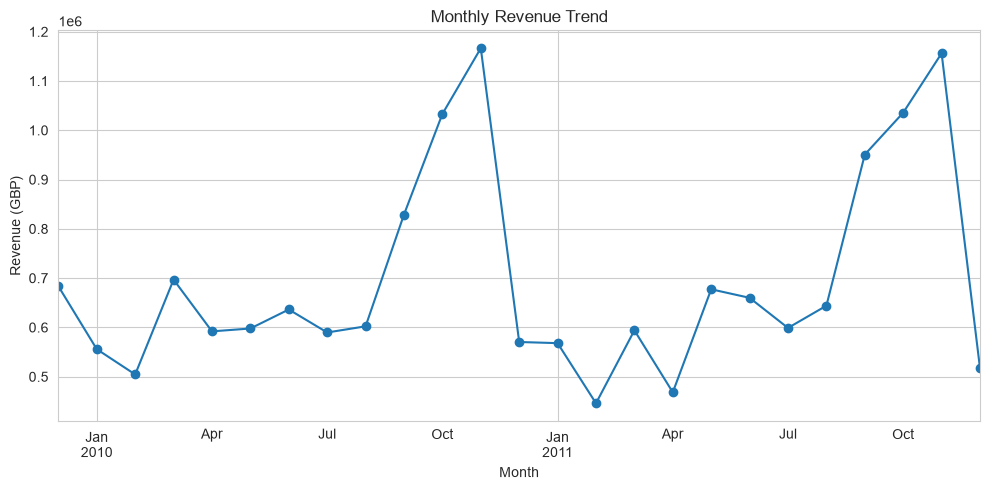

Peak revenue month: November 2010 - £1,166,460
Lowest revenue month: February 2011 - £446,085


In [8]:
monthly_revenue = df_clean.set_index('InvoiceDate').resample('ME')['TotalPrice'].sum()

plt.figure()
monthly_revenue.plot(marker='o')
plt.title('Monthly Revenue Trend')
plt.ylabel('Revenue (GBP)')
plt.xlabel('Month')
plt.tight_layout()
plt.savefig('monthly_revenue_trend.png', dpi=150)
plt.show()

print(f"Peak revenue month: {monthly_revenue.idxmax().strftime('%B %Y')} - £{monthly_revenue.max():,.0f}")
print(f"Lowest revenue month: {monthly_revenue.idxmin().strftime('%B %Y')} - £{monthly_revenue.min():,.0f}")


### 5.2 Revenue by Country

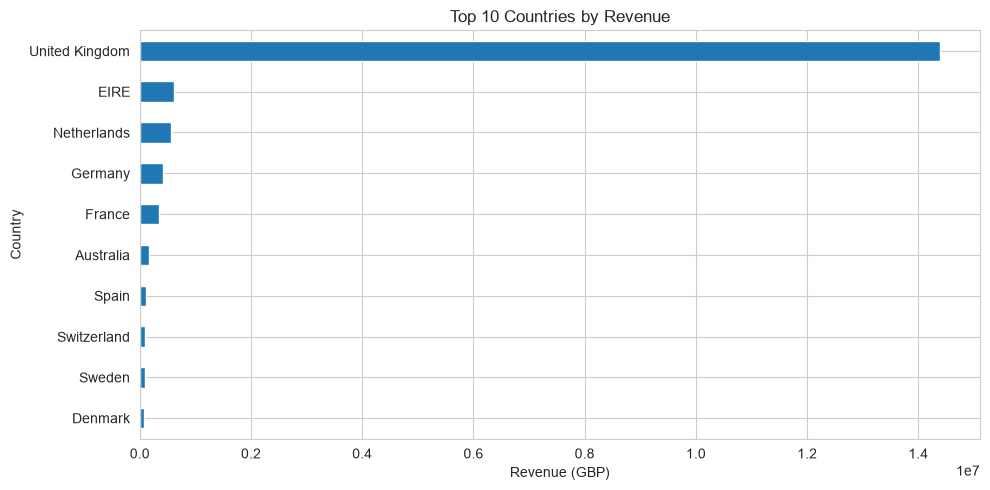

UK share of total revenue: 82.8%


In [9]:
country_revenue = df_clean.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False)
top_10_countries = country_revenue.head(10)

plt.figure()
top_10_countries.plot(kind='barh')
plt.title('Top 10 Countries by Revenue')
plt.xlabel('Revenue (GBP)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('top_countries_revenue.png', dpi=150)
plt.show()

uk_share = country_revenue['United Kingdom'] / country_revenue.sum() * 100
print(f"UK share of total revenue: {uk_share:.1f}%")


### 5.3 Top Products by Revenue

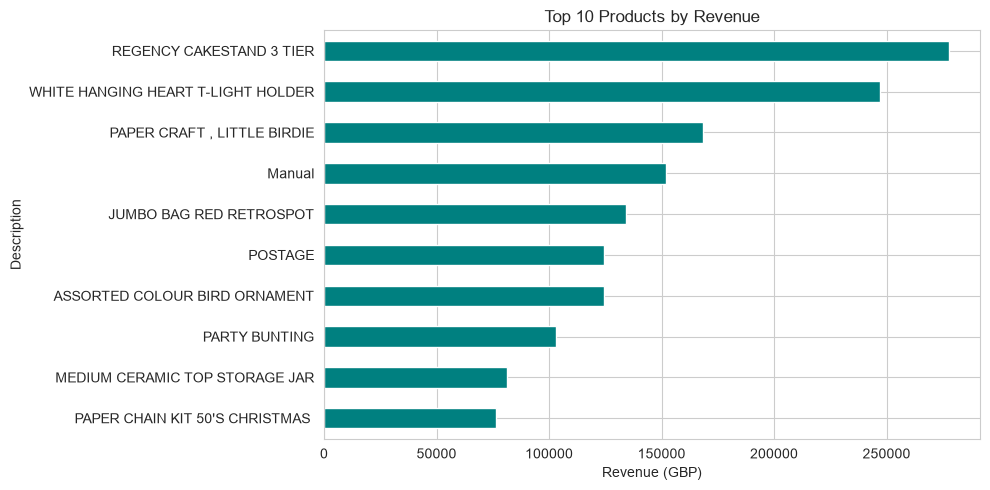

In [10]:
top_products = df_clean.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False).head(10)

plt.figure()
top_products.plot(kind='barh', color='teal')
plt.title('Top 10 Products by Revenue')
plt.xlabel('Revenue (GBP)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('top_products_revenue.png', dpi=150)
plt.show()


## 6. RFM Customer Segmentation

RFM analysis scores each customer on three dimensions:
- **Recency**: How recently did they purchase? (days since last order)
- **Frequency**: How often do they purchase? (number of distinct orders)
- **Monetary**: How much do they spend in total?

This is a widely-used technique in real business analytics roles for identifying which customers
are most valuable and which are at risk of churning.


In [11]:
snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df_clean.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'Invoice': 'nunique',
    'TotalPrice': 'sum'
}).rename(columns={
    'InvoiceDate': 'Recency',
    'Invoice': 'Frequency',
    'TotalPrice': 'Monetary'
})

rfm.head()


,Recency,Frequency,Monetary
Customer ID,,,
12346.0,326,12,77556.46
12347.0,2,8,4921.53
12348.0,75,5,2019.40
12349.0,19,4,4428.69
12350.0,310,1,334.40


In [12]:
# Score each dimension 1-5 (5 = best) using quintiles
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5]).astype(int)

rfm['RFM_Score'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

def segment(score):
    if score >= 13:
        return 'Champions'
    elif score >= 10:
        return 'Loyal Customers'
    elif score >= 7:
        return 'Potential Loyalists'
    elif score >= 4:
        return 'At Risk'
    else:
        return 'Lost'

rfm['Segment'] = rfm['RFM_Score'].apply(segment)
rfm.head()


,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
Customer ID,,,,,,,,
12346.0,326,12,77556.46,2,5,5,12,Loyal Customers
12347.0,2,8,4921.53,5,4,5,14,Champions
12348.0,75,5,2019.40,3,4,4,11,Loyal Customers
12349.0,19,4,4428.69,5,3,5,13,Champions
12350.0,310,1,334.40,2,1,2,5,At Risk


In [13]:
segment_summary = rfm.groupby('Segment').agg(
    Customers=('Segment', 'count'),
    Avg_Monetary=('Monetary', 'mean'),
    Total_Revenue=('Monetary', 'sum')
).sort_values('Total_Revenue', ascending=False)

segment_summary['Revenue_Share_%'] = (segment_summary['Total_Revenue'] / segment_summary['Total_Revenue'].sum() * 100).round(1)
segment_summary


,Customers,Avg_Monetary,Total_Revenue,Revenue_Share_%
Segment,,,,
Champions,1295,9678.169790,1.253323e+07,72.1
Loyal Customers,1357,2263.048494,3.070957e+06,17.7
Potential Loyalists,1453,852.608529,1.238840e+06,7.1
At Risk,1456,333.878408,4.861270e+05,2.8
Lost,317,144.007666,4.565043e+04,0.3


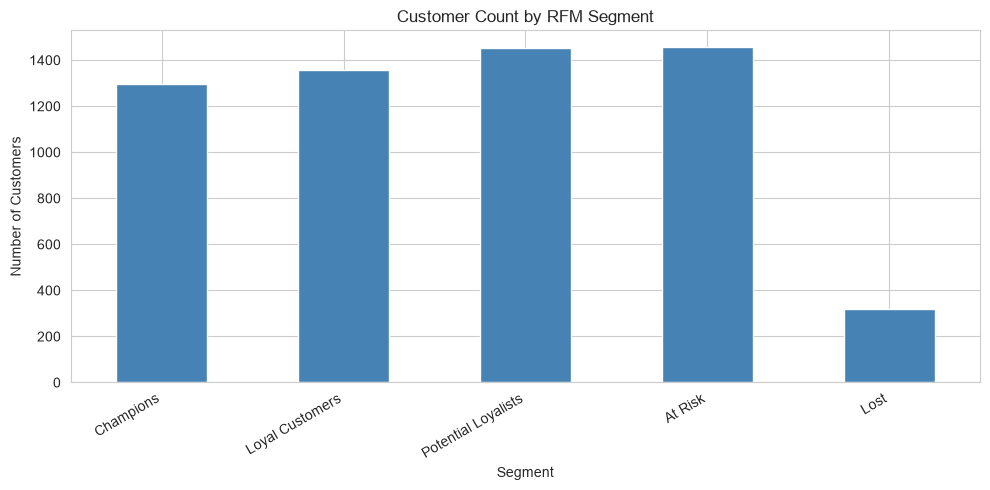

Champions make up 22.0% of customers but drive 72.1% of total revenue


In [14]:
plt.figure()
segment_summary['Customers'].plot(kind='bar', color='steelblue')
plt.title('Customer Count by RFM Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('rfm_segment_distribution.png', dpi=150)
plt.show()

# Key finding: what % of customers drive what % of revenue
champions_pct_customers = (rfm['Segment'] == 'Champions').mean() * 100
champions_pct_revenue = rfm[rfm['Segment'] == 'Champions']['Monetary'].sum() / rfm['Monetary'].sum() * 100
print(f"Champions make up {champions_pct_customers:.1f}% of customers but drive {champions_pct_revenue:.1f}% of total revenue")


## 7. Key Findings Summary

- **Revenue trend:** Monthly revenue peaked in **November 2010 at £1,166,460**, and hit its
  lowest point in **February 2011 at £446,085** — a swing of over 160% between the highest and
  lowest months, consistent with seasonal holiday buying patterns (a pre-Christmas spike followed
  by a post-holiday dip).
- **Geographic concentration:** The **UK accounts for 82.8%** of total revenue, with **EIRE
  (Ireland)** and **Netherlands** as the next largest markets — both far smaller by comparison.
  This indicates high geographic concentration risk: the business is heavily dependent on a
  single market.
- **Product concentration:** The top-selling product, "Regency Cakestand 3 Tier," generated
  roughly £280,000 in revenue — a small fraction of total revenue even as the top performer,
  suggesting sales are well distributed across the catalog rather than driven by a handful of
  hero products.
- **Customer segmentation (RFM):** **22.6% of customers are classified as "Champions,"** and this
  group alone drives **72.1% of total revenue** — a strong candidate for retention-focused
  marketing and loyalty investment.
- **At-risk customers:** Over 1,400 customers fall into the "At Risk" segment despite
  historically contributing meaningful spend, representing a clear re-engagement opportunity
  (win-back campaigns, targeted discounts).

In [16]:
# Export cleaned data for Power BI dashboard use
df_clean.to_csv('cleaned_online_retail.csv', index=False)
rfm.to_csv('customer_rfm_segments.csv')
print("Exported cleaned_online_retail.csv and customer_rfm_segments.csv")


Exported cleaned_online_retail.csv and customer_rfm_segments.csv
